In [47]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering





# 1. CSV-Dateien einlesen (Pfad zu realen und synthetischen Daten anpassen)
real_path = "../../data/data_for_CTGAN/CTGAN_basedata.csv"
syn_path1 = "../../data/synthetic_result_data/536_synthetic_train_data.csv"
syn_path2 = "../../data/synthetic_result_data/536_synthetic.csv"


df_real = pd.read_csv(real_path)
df_syn1 = pd.read_csv(syn_path1)
df_syn2 = pd.read_csv(syn_path2)



In [48]:
def compute_structural_similarity_score(original: pd.DataFrame,
                                        synthetic: pd.DataFrame,
                                        eps=0.5,
                                        min_samples=5,
                                        weights=None):
    """
    Computes a universal structural similarity score ∈ [0,1], where 1 is best.
    Integrates:
      - Cluster Purity (KMeans & DBSCAN)
      - Adjusted Rand Index (KMeans & DBSCAN)
      - Cosine Similarity of global mean feature vectors
    Each subscore ∈ [0,1]; final score is the average.
    """
    # Preprocessing: one-hot encode categorical + standardize numeric
    num_cols = original.select_dtypes(include=[np.number]).columns.intersection(
               synthetic.select_dtypes(include=[np.number]).columns)
    cat_cols = original.select_dtypes(exclude=[np.number]).columns.intersection(
               synthetic.select_dtypes(exclude=[np.number]).columns)
    
    if len(cat_cols) > 0:
        combined_cat = pd.concat([original[cat_cols], synthetic[cat_cols]], axis=0)
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoder.fit(combined_cat)
        orig_cat = encoder.transform(original[cat_cols])
        syn_cat = encoder.transform(synthetic[cat_cols])
    else:
        orig_cat = np.empty((len(original), 0))
        syn_cat = np.empty((len(synthetic), 0))
    
    orig_num = original[num_cols].to_numpy()
    syn_num  = synthetic[num_cols].to_numpy()
    scaler = StandardScaler().fit(np.vstack([orig_num, syn_num]))
    orig_num = scaler.transform(orig_num)
    syn_num  = scaler.transform(syn_num)
    
    # Feature matrices
    X_orig = np.hstack([orig_num, orig_cat])
    X_syn  = np.hstack([syn_num,  syn_cat])
    labels = np.concatenate([np.zeros(len(X_orig)), np.ones(len(X_syn))])
    X_joint = np.vstack([X_orig, X_syn])
    
    # 1. Cluster Purity Subscores
    def purity_subscore(cl_labels):
        subs = []
        for c in np.unique(cl_labels):
            mask = (cl_labels == c)
            counts = np.bincount(labels[mask].astype(int), minlength=2)
            if counts.sum() == 0: continue
            purity = counts.max() / counts.sum()
            # Map purity 0.5->1.0, purity 1.0->0.0
            subs.append(max(0, 1 - abs(purity - 0.5) / 0.5))
        return np.mean(subs) if subs else 0.0
    
    km_labels = KMeans(n_clusters=2, random_state=42).fit_predict(X_joint)
    db_labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_joint)
    s_purity_km = purity_subscore(km_labels)
    s_purity_db = purity_subscore(db_labels)
    
    # 2. ARI Subscores
    s_ari_km = 1 - abs(adjusted_rand_score(labels, km_labels))
    s_ari_db = 1 - abs(adjusted_rand_score(labels, db_labels))
    
    # 3. Cosine Similarity Subscore
    vec_orig = X_orig.mean(axis=0).reshape(1, -1)
    vec_syn  = X_syn.mean(axis=0).reshape(1, -1)
    cos_val = cosine_similarity(vec_orig, vec_syn)[0, 0]
    s_cos = (cos_val + 1) / 2  
    
    # Default equal weights across 5 subscores
    if weights is None:
        weights = {
            'purity_km': 0.15,
            'purity_db': 0.15,
            'ARI_km':    0.15,
            'ARI_db':    0.15,
            'cosine':    0.40
        } 
    
    # Combine
    structural_score = (
        weights['purity_km'] * s_purity_km +
        weights['purity_db'] * s_purity_db +
        weights['ARI_km']    * s_ari_km +
        weights['ARI_db']    * s_ari_db +
        weights['cosine']    * s_cos
    )
    
    return round(float(structural_score), 4)



In [49]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

def visualize_structural_consistency(original: pd.DataFrame,
                                     synthetic: pd.DataFrame,
                                     eps=0.5,
                                     min_samples=5):
    num_cols = original.select_dtypes(include=[np.number]).columns.intersection(
               synthetic.select_dtypes(include=[np.number]).columns)
    cat_cols = original.select_dtypes(exclude=[np.number]).columns.intersection(
               synthetic.select_dtypes(exclude=[np.number]).columns)

    if len(cat_cols) > 0:
        combined_cat = pd.concat([original[cat_cols], synthetic[cat_cols]], axis=0)
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoder.fit(combined_cat)
        orig_cat = encoder.transform(original[cat_cols])
        syn_cat = encoder.transform(synthetic[cat_cols])
    else:
        orig_cat = np.empty((len(original), 0))
        syn_cat = np.empty((len(synthetic), 0))

    orig_num = original[num_cols].to_numpy()
    syn_num  = synthetic[num_cols].to_numpy()
    scaler = StandardScaler()
    scaler.fit(np.vstack([orig_num, syn_num]))
    orig_num = scaler.transform(orig_num)
    syn_num  = scaler.transform(syn_num)

    X_orig = np.hstack([orig_num, orig_cat])
    X_syn  = np.hstack([syn_num,  syn_cat])
    labels_orig = np.zeros(len(X_orig), dtype=int)
    labels_syn  = np.ones(len(X_syn),  dtype=int)

    X_joint = np.vstack([X_orig, X_syn])
    labels = np.concatenate([labels_orig, labels_syn])

    color_map = {0: '#1f77b4', 1: '#ff7f0e'}

    # t-SNE
    tsne_joint = TSNE(n_components=2, random_state=42).fit_transform(X_joint)

    # Clustering
    agg_cluster = AgglomerativeClustering(n_clusters=2).fit(tsne_joint)
    cluster_labels = agg_cluster.labels_

    # Zentroiden berechnen
    centroids = []
    for label in np.unique(cluster_labels):
        points = tsne_joint[cluster_labels == label]
        centroid = points.mean(axis=0)
        centroids.append(centroid)
    centroids = np.array(centroids)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(tsne_joint[:, 0], tsne_joint[:, 1],
                c=[color_map[label] if label in color_map else 'gray' for label in cluster_labels],
                alpha=0.6)
    plt.title("Agglomerative Clustering on Joint t-SNE")
    plt.show()


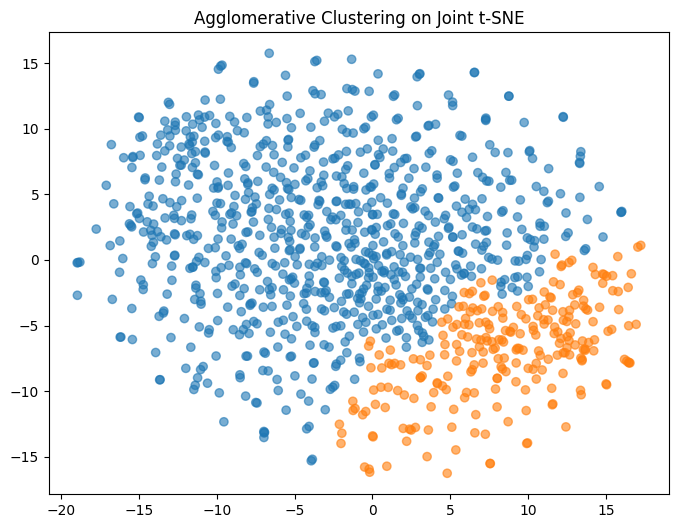

In [50]:
visualize_structural_consistency(df_real,df_syn1)

In [51]:

sim_score = compute_structural_similarity_score(df_real, df_real)
print("Structure Consistency Score:", sim_score)


sim_score = compute_structural_similarity_score(df_real, df_syn1)
print("Structure Consistency Score:", sim_score)


sim_score = compute_structural_similarity_score(df_real, df_syn2)
print("Structure Consistency Score:", sim_score)


Structure Consistency Score: 0.9999
Structure Consistency Score: 0.8984
Structure Consistency Score: 0.8684


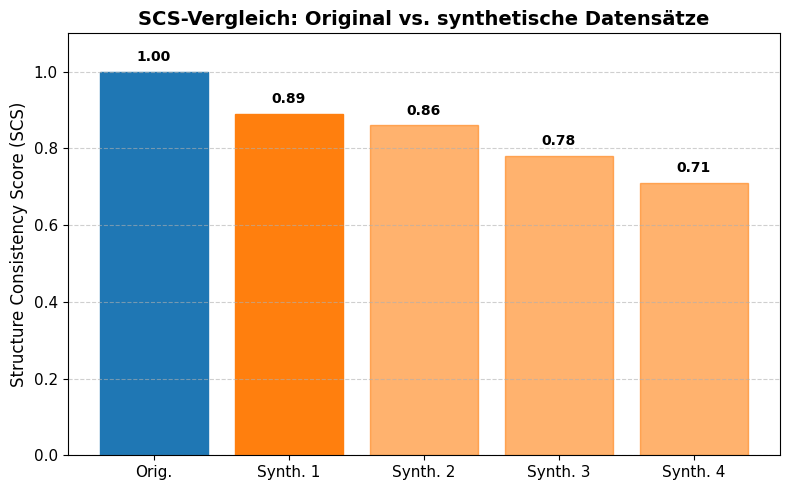

In [52]:
import matplotlib.pyplot as plt

# Daten für das Diagramm
sss_scores = {
    "Orig.": 1.0,
    "Synth. 1": 0.89,
    "Synth. 2": 0.86,
    "Synth. 3": 0.78,
    "Synth. 4": 0.71,
}

# Erstellen der Figur und der Achsen
plt.figure(figsize=(8, 5))

# Farben definieren
color_original = '#1f77b4'  # Blau für "Original"
color_synthetic = '#ff7f0e' # Orange für "Synthetisch"

# Balkendiagramm erstellen
bars = plt.bar(sss_scores.keys(), sss_scores.values(), edgecolor='black')

# Farbe für den "Original"-Balken (blau)
bars[0].set_color(color_original)

# Farbe für den ersten "Synthetisch"-Balken (dunkles Orange)
bars[1].set_color(color_synthetic)

# Farbe und Transparenz für die restlichen "Synthetisch"-Balken (blasses Orange)
for bar in bars[2:]:
    bar.set_color(color_synthetic)
    bar.set_alpha(0.6)  # Alpha-Wert für einen "blassen" Effekt

# Beschriftungen über den Balken hinzufügen
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.02, f"{yval:.2f}",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Titel und Achsenbeschriftungen
plt.ylabel("Structure Consistency Score (SCS)", fontsize=12)
plt.title("SCS-Vergleich: Original vs. synthetische Datensätze", fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()

# Diagramm anzeigen
plt.show()

 

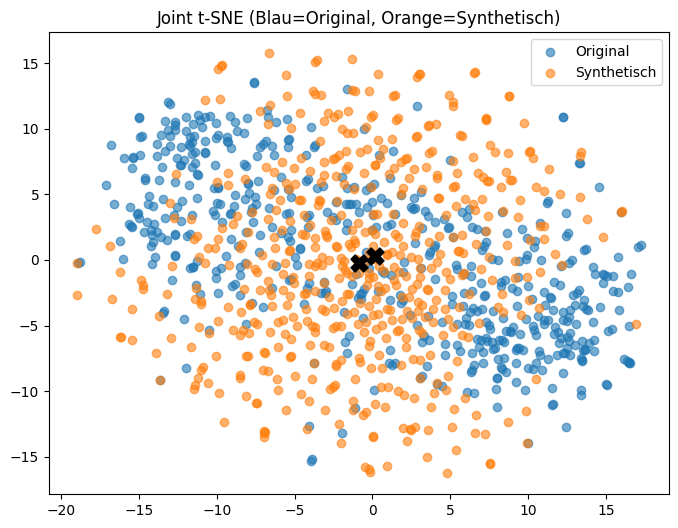

In [53]:
def centroide(original: pd.DataFrame,
              synthetic: pd.DataFrame,
              eps=0.5,
              min_samples=5):
    
    # numerische & kategoriale Spalten extrahieren
    num_cols = original.select_dtypes(include=[np.number]).columns.intersection(
               synthetic.select_dtypes(include=[np.number]).columns)
    cat_cols = original.select_dtypes(exclude=[np.number]).columns.intersection(
               synthetic.select_dtypes(exclude=[np.number]).columns)
    
    # Kategoriale Features One-Hot-Enkodieren
    if len(cat_cols) > 0:
        combined_cat = pd.concat([original[cat_cols], synthetic[cat_cols]], axis=0)
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoder.fit(combined_cat)
        orig_cat = encoder.transform(original[cat_cols])
        syn_cat = encoder.transform(synthetic[cat_cols])
    else:
        orig_cat = np.empty((len(original), 0))
        syn_cat = np.empty((len(synthetic), 0))
    
    # Numerische Features skalieren
    orig_num = original[num_cols].to_numpy()
    syn_num  = synthetic[num_cols].to_numpy()
    scaler = StandardScaler()
    scaler.fit(np.vstack([orig_num, syn_num]))
    orig_num = scaler.transform(orig_num)
    syn_num  = scaler.transform(syn_num)
    
    # Kombinieren
    X_orig = np.hstack([orig_num, orig_cat])
    X_syn  = np.hstack([syn_num,  syn_cat])
    labels_orig = np.zeros(len(X_orig), dtype=int)   # 0 = Original
    labels_syn  = np.ones(len(X_syn),  dtype=int)    # 1 = Synthetisch

    X_joint = np.vstack([X_orig, X_syn])
    labels = np.concatenate([labels_orig, labels_syn])

    # Farben: 0 -> Blau, 1 -> Orange
    color_map = {0: '#1f77b4', 1: '#ff7f0e'}

    # t-SNE
    tsne_joint = TSNE(n_components=2, random_state=42).fit_transform(X_joint)

    # Zentroiden pro Klasse (Original/Synthetisch)
    centroids = []
    for label in np.unique(labels):
        points = tsne_joint[labels == label]
        centroid = points.mean(axis=0)
        centroids.append(centroid)
    centroids = np.array(centroids)

    # Plot
    plt.figure(figsize=(8, 6))
    for label in np.unique(labels):
        idx = labels == label
        plt.scatter(tsne_joint[idx, 0], tsne_joint[idx, 1],
                    c=color_map[label],
                    label="Original" if label == 0 else "Synthetisch",
                    alpha=0.6)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                c='black', marker='X', s=150)  # Zentroiden in Schwarz
    plt.title('Joint t-SNE (Blau=Original, Orange=Synthetisch)')
    plt.legend()
    plt.show()


centroide(df_real,df_syn1)
